# §4 Individual with ML#2 filter — net of costs

Per-combo metrics and equity/drawdown curves after applying the V3
booster + pooled-R:R isotonic calibrator filter.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick). Applied to both sizing policies.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0)
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 10 strategies.
Loaded results_raw from cache (10 combos).
Combined unfiltered trades: 11,851


Loaded combos_ml2 from cache (10 combos).
ML2 portfolio trade counts: {'fixed_dollars_500': 119, 'pct5_compound': 119}


In [2]:
rows = []
for cid, entry in s4_pnl_by_combo.items():
    pnl_base = entry['pnl_base']; risk_base = entry['risk_base']
    if len(pnl_base) == 0:
        for policy in POLICIES:
            rows.append({'combo_id': cid, 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = entry['by_policy'][policy]
        rows.append({'combo_id': cid, 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf4 = pd.DataFrame(rows)
perf4

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_9955,fixed_dollars_500,165,112.9,0.6970,1455.53,2.91,0.1703,11.92,6092.67
1,v10_9955,pct5_compound,165,112.9,0.6970,-5305.05,-10.61,-0.1277,54.59,30456.85
2,v5_2725,fixed_dollars_500,21,14.4,0.8571,3925.99,7.85,1.9657,3.75,2025.00
3,v5_2725,pct5_compound,21,14.4,0.8571,23073.16,46.15,1.8464,19.09,14158.23
4,v9_837,fixed_dollars_500,13,8.9,0.7692,-1251.78,-2.50,-0.6568,4.90,2456.37
5,v9_837,pct5_compound,13,8.9,0.7692,-6530.47,-13.06,-0.6973,22.99,11649.99
6,v10_4391,fixed_dollars_500,150,102.7,0.7467,4829.85,9.66,0.6159,12.11,6569.65
7,v10_4391,pct5_compound,150,102.7,0.7467,15115.66,30.23,0.3249,51.08,35427.05
8,v10_1214,fixed_dollars_500,29,19.8,0.6552,1724.46,3.45,0.4737,4.85,2498.31
9,v10_1214,pct5_compound,29,19.8,0.6552,6861.47,13.72,0.3429,23.38,13538.33


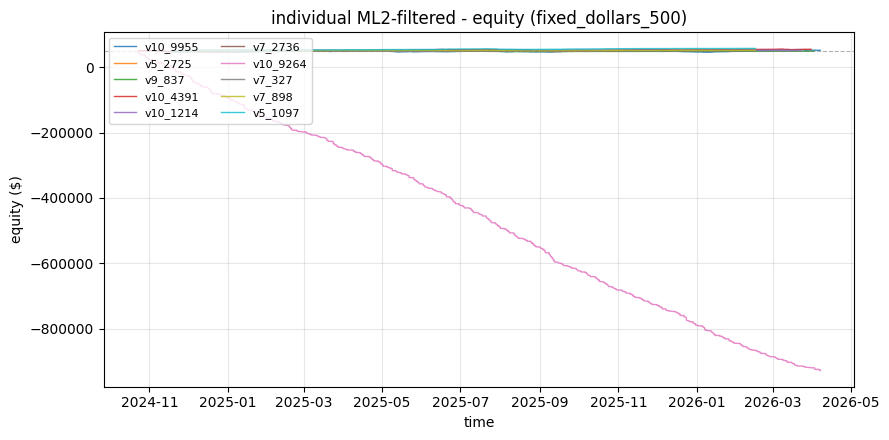

In [3]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'fixed_dollars_500')

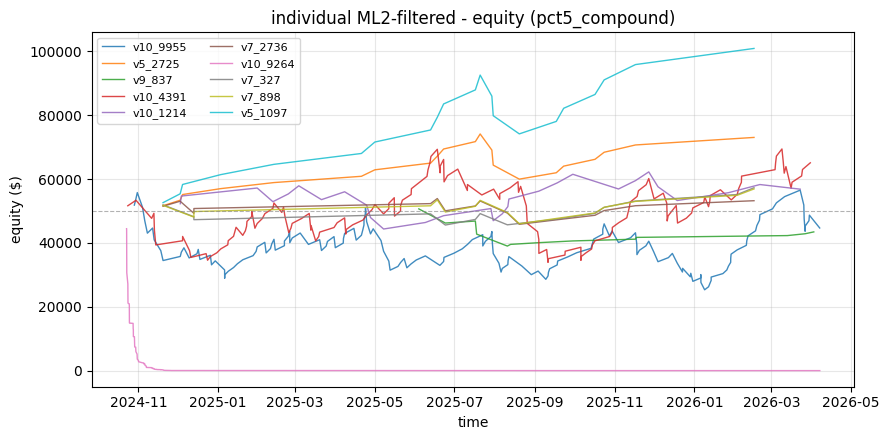

In [4]:
plot_ml2_indiv_equity(s4_pnl_by_combo, bars, 'pct5_compound')

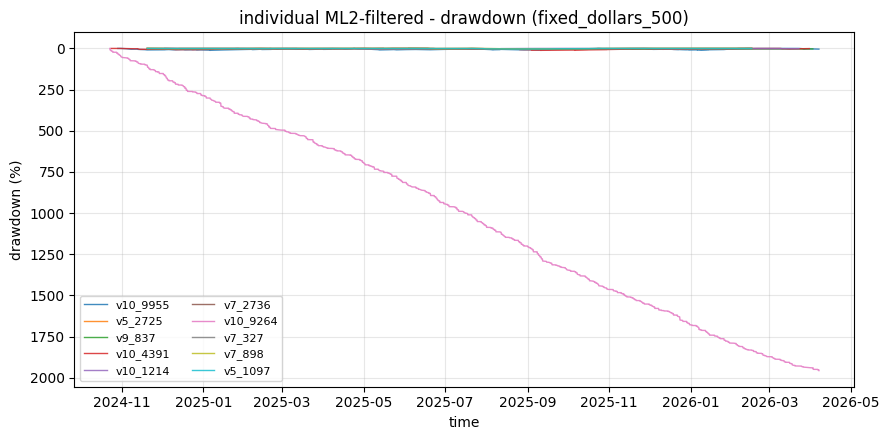

In [5]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'fixed_dollars_500')

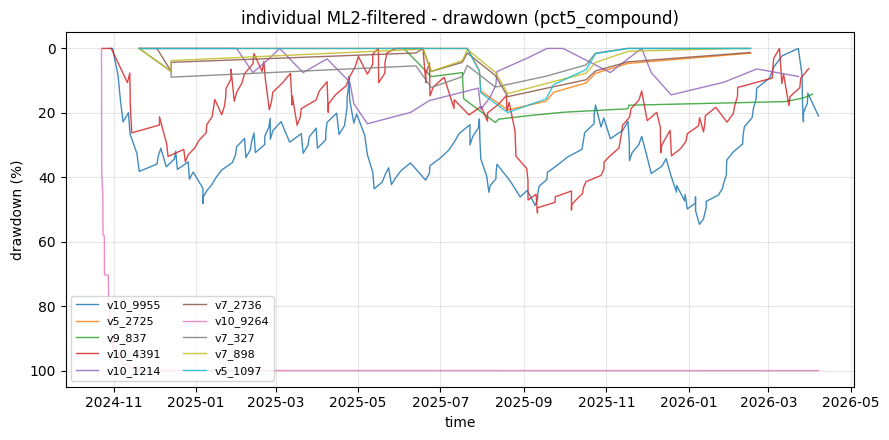

In [6]:
plot_ml2_indiv_dd(s4_pnl_by_combo, bars, 'pct5_compound')